# Part III: Language Task — News Headline Classification using RNN, LSTM, and Word Embeddings

**Dataset:** `news_category.csv`  
**Task:** Multi-class text classification using news headlines.  
**Models:** Simple RNN, LSTM, and LSTM with pretrained GloVe/Word2Vec-style embeddings.

This notebook follows the Part III requirements: text preprocessing, tokenization, sequence padding, RNN/LSTM models, pretrained embeddings, evaluation, error analysis, and optional real-time prediction interface.

## 1. Install Required Libraries

Run this cell once. If using VS Code/Jupyter locally, remove the `!` commands and install from terminal if needed.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Import Libraries and Set Random Seeds

In [4]:
import os
import re
import time
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


3. Define File Paths and Output Folders


In [5]:
from google.colab import drive
drive.mount("/content/drive")

DATA_PATH = "/content/drive/MyDrive/6. News Category Dataset/news_category.csv"

OUTPUT_DIR = "/content/drive/MyDrive/6. News Category Dataset/outputs_nlp"
GRAPH_DIR = os.path.join(OUTPUT_DIR, "graphs")
RESULT_DIR = os.path.join(OUTPUT_DIR, "results")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")

for folder in [OUTPUT_DIR, GRAPH_DIR, RESULT_DIR, MODEL_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Dataset path:", DATA_PATH)
print("Dataset exists:", os.path.exists(DATA_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset path: /content/drive/MyDrive/6. News Category Dataset/news_category.csv
Dataset exists: True


## 4. Load Dataset and Basic Understanding

In [6]:
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())
print("Columns:", df.columns.tolist())
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Dataset shape: (11025, 2)


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS


Columns: ['headline', 'category']
Missing values:
 headline    0
category    0
dtype: int64
Duplicate rows: 78


In [7]:
# Expected columns in this dataset: headline and category
TEXT_COL = "headline"
LABEL_COL = "category"

# Remove missing/duplicate rows if any
df = df[[TEXT_COL, LABEL_COL]].dropna().drop_duplicates().reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)
print("Number of classes:", df[LABEL_COL].nunique())
print("Classes:", sorted(df[LABEL_COL].unique()))

Cleaned dataset shape: (10947, 2)
Number of classes: 5
Classes: ['CULTURE & ARTS', 'EDUCATION', 'MONEY', 'SPORTS', 'TECH']


## 5. Class Distribution Visualization

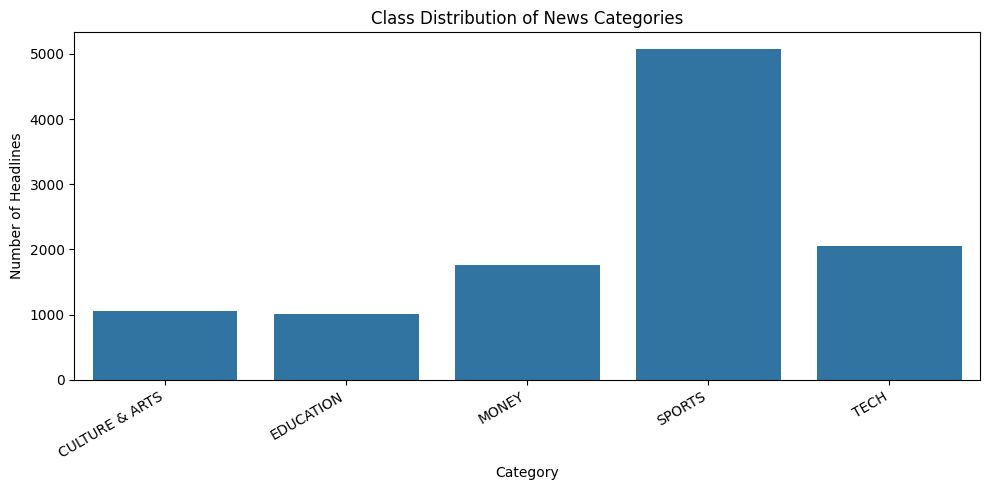

,count
category,
CULTURE & ARTS,1054
EDUCATION,1014
MONEY,1754
SPORTS,5076
TECH,2049


In [8]:
class_counts = df[LABEL_COL].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution of News Categories")
plt.xlabel("Category")
plt.ylabel("Number of Headlines")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "class_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

class_counts

## 6. Text Preprocessing



In [9]:
# Simple contraction dictionary for common English contractions
CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "can't": "cannot", "couldn't": "could not", "shouldn't": "should not",
    "won't": "will not", "wouldn't": "would not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "you're": "you are", "you've": "you have", "you'll": "you will",
    "he's": "he is", "she's": "she is", "it's": "it is", "that's": "that is",
    "there's": "there is", "what's": "what is", "who's": "who is",
    "they're": "they are", "we're": "we are", "n't": " not",
    "'re": " are", "'s": " is", "'d": " would", "'ll": " will", "'t": " not", "'ve": " have", "'m": " am"
}

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def expand_contractions(text):
    text = str(text)
    for contraction, full_form in CONTRACTIONS.items():
        text = re.sub(re.escape(contraction), full_form, text, flags=re.IGNORECASE)
    return text

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)  # remove URLs
    text = re.sub(r"@\w+", " ", text)  # remove mentions
    text = re.sub(r"#", " ", text)  # remove hashtag symbol but keep word
    text = re.sub(r"\d+", " ", text)  # remove numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)  # remove special characters
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 1]
    return " ".join(tokens)

df["clean_text"] = df[TEXT_COL].apply(clean_text)

# Remove empty cleaned rows if any
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

display(df[[TEXT_COL, "clean_text", LABEL_COL]].head(10))
print("Dataset shape after cleaning:", df.shape)

,headline,clean_text,category
0,How A New Documentary Captures The Complexity ...,new documentary capture complexity child immig...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,twitch ban gambling site streamer scam folk,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,areboot clever navel gazey look inside tv reboots,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",maury will base stealing shortstop dodger dy,SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",la vega ace win first wnba title chelsea gray ...,SPORTS
5,"Meet Alex Aster, The TikToker Changing The Pub...",meet alex aster tiktoker changing publishing i...,CULTURE & ARTS
6,TikTok Search Results Riddled With Misinformat...,tiktok search result riddled misinformation re...,TECH
7,Boston Marathon To Make Race More Inclusive Fo...,boston marathon make race inclusive nonbinary ...,SPORTS
8,"Anthony Varvaro, MLB Pitcher Turned Transit Co...",anthony varvaro mlb pitcher turned transit cop...,SPORTS
9,How Ani Liu Is Brilliantly Disguising Her Art ...,ani liu brilliantly disguising art science,CULTURE & ARTS


Dataset shape after cleaning: (10947, 3)


## 7. Cleaned Text Visualization

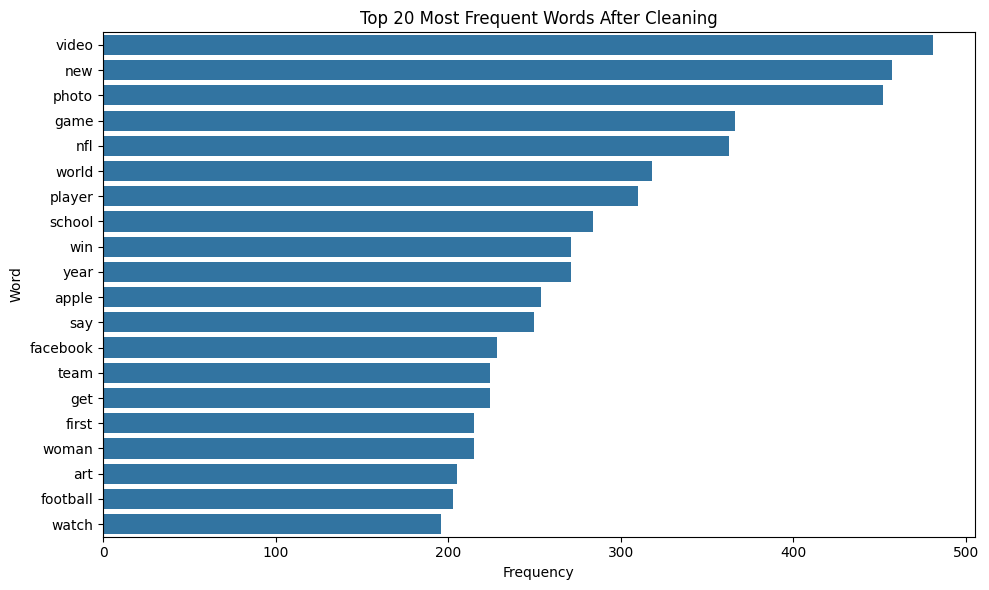

,word,count
0,video,481
1,new,457
2,photo,452
3,game,366
4,nfl,363
5,world,318
6,player,310
7,school,284
8,win,271
9,year,271


In [10]:
from collections import Counter

all_words = " ".join(df["clean_text"]).split()
word_counts = Counter(all_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=["word", "count"])

plt.figure(figsize=(10, 6))
sns.barplot(data=common_words, x="count", y="word")
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "top_20_words.png"), dpi=300, bbox_inches="tight")
plt.show()

display(common_words)

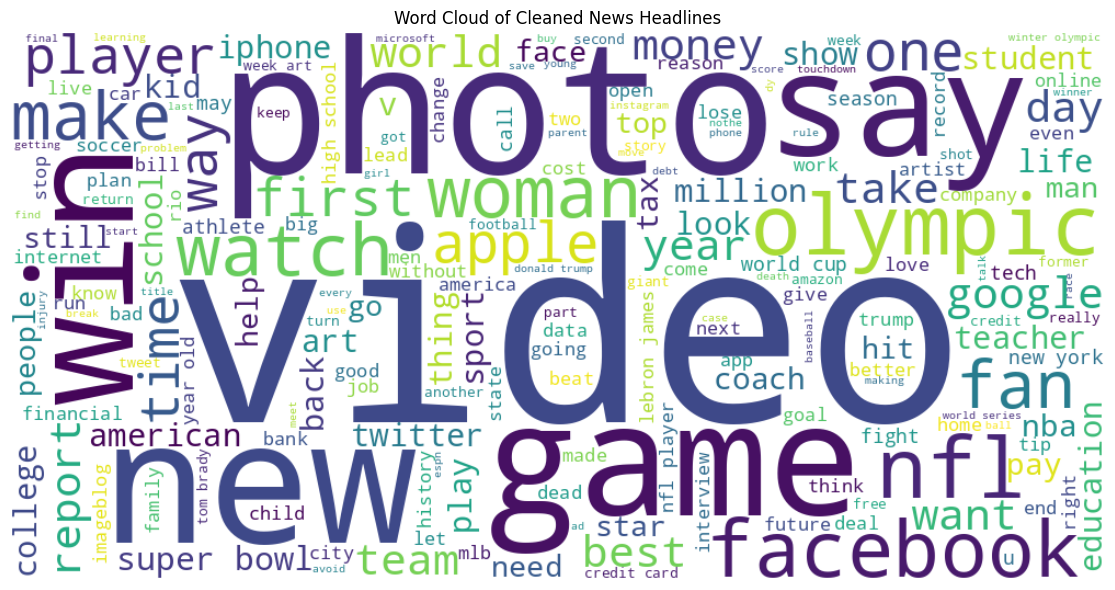

In [11]:
# Optional word cloud visualization
try:
    from wordcloud import WordCloud
    wordcloud = WordCloud(width=1000, height=500, background_color="white").generate(" ".join(df["clean_text"]))
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Cleaned News Headlines")
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPH_DIR, "wordcloud.png"), dpi=300, bbox_inches="tight")
    plt.show()
except Exception as e:
    print("WordCloud not available. Error:", e)

## 8. Encode Labels and Train-Test Split

In [12]:
label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df[LABEL_COL])
class_names = list(label_encoder.classes_)
NUM_CLASSES = len(class_names)

print("Class mapping:")
for i, cls in enumerate(class_names):
    print(i, "=>", cls)

X = df["clean_text"].values
y = df["label_encoded"].values

X_train, X_test, y_train_int, y_test_int = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

y_train = to_categorical(y_train_int, num_classes=NUM_CLASSES)
y_test = to_categorical(y_test_int, num_classes=NUM_CLASSES)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Number of classes:", NUM_CLASSES)

Class mapping:
0 => CULTURE & ARTS
1 => EDUCATION
2 => MONEY
3 => SPORTS
4 => TECH
Training samples: 8757
Testing samples: 2190
Number of classes: 5


## 9. Tokenization and Percentile-Based Padding

Vocabulary size: 11491
95th percentile max sequence length: 11
X_train_pad shape: (8757, 11)
X_test_pad shape: (2190, 11)


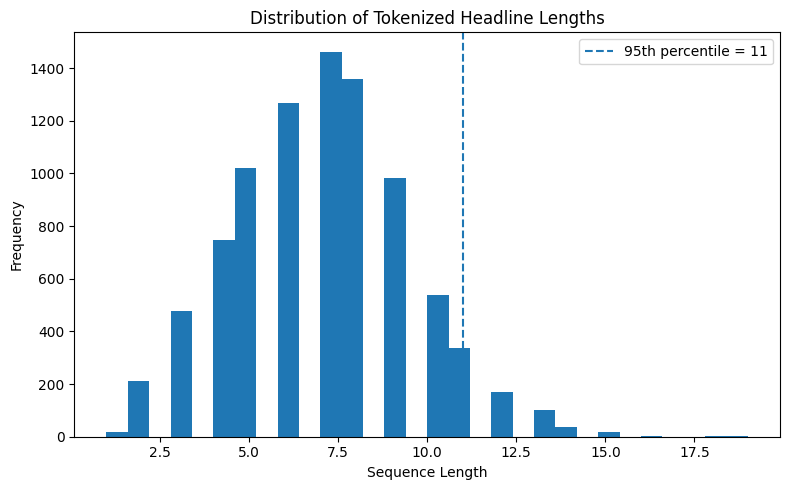

In [13]:
MAX_WORDS = 20000
OOV_TOKEN = "<OOV>"

# Tokenizer learns vocabulary from training data only
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding: avoids using extreme outlier sequence lengths
sequence_lengths = [len(seq) for seq in train_sequences]
MAX_LEN = int(np.percentile(sequence_lengths, 95))
MAX_LEN = max(MAX_LEN, 5)  # safety minimum for very short headline data

X_train_pad = pad_sequences(train_sequences, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(test_sequences, maxlen=MAX_LEN, padding="post", truncating="post")

VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)

print("Vocabulary size:", VOCAB_SIZE)
print("95th percentile max sequence length:", MAX_LEN)
print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

plt.figure(figsize=(8, 5))
plt.hist(sequence_lengths, bins=30)
plt.axvline(MAX_LEN, linestyle="--", label=f"95th percentile = {MAX_LEN}")
plt.title("Distribution of Tokenized Headline Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "sequence_length_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

## 10. Class Weights and Helper Functions

In [14]:
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weights = {i: weight for i, weight in enumerate(class_weights_values)}
print("Class weights:", class_weights)

def make_callbacks():
    return [
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)
    ]

def plot_history(history, model_name):
    # Accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name}: Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPH_DIR, f"{model_name.lower().replace(' ', '_')}_accuracy.png"), dpi=300, bbox_inches="tight")
    plt.show()

    # Loss
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name}: Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPH_DIR, f"{model_name.lower().replace(' ', '_')}_loss.png"), dpi=300, bbox_inches="tight")
    plt.show()

def evaluate_model(model, X_test_data, y_test_cat, y_test_int, model_name):
    y_pred_probs = model.predict(X_test_data, verbose=0)
    y_pred_int = np.argmax(y_pred_probs, axis=1)

    accuracy = accuracy_score(y_test_int, y_pred_int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test_int, y_pred_int, average="weighted", zero_division=0
    )

    print(f"\n{model_name} Results")
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-score :", round(f1, 4))

    report = classification_report(y_test_int, y_pred_int, target_names=class_names, zero_division=0)
    print("\nClassification Report:\n", report)

    with open(os.path.join(RESULT_DIR, f"{model_name.lower().replace(' ', '_')}_classification_report.txt"), "w") as f:
        f.write(report)

    cm = confusion_matrix(y_test_int, y_pred_int)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{model_name}: Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPH_DIR, f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png"), dpi=300, bbox_inches="tight")
    plt.show()

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }, y_pred_int, y_pred_probs

def save_model_summary(model, model_name):
    summary_path = os.path.join(RESULT_DIR, f"{model_name.lower().replace(' ', '_')}_model_summary.txt")
    with open(summary_path, "w", encoding="utf-8") as f:
        model.summary(print_fn=lambda x: f.write(x + "\n"))
    print(f"Model summary saved to: {summary_path}")

Class weights: {0: np.float64(2.0775800711743773), 1: np.float64(2.159556103575832), 2: np.float64(1.2483250178189593), 3: np.float64(0.43127308544693427), 4: np.float64(1.0685784014643076)}


## 11. Model 1 — Simple RNN with Trainable Embedding Layer

In [15]:
EMBEDDING_DIM = 128
RNN_EPOCHS = 8
BATCH_SIZE = 64

rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

rnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

rnn_model.summary()
save_model_summary(rnn_model, "Simple RNN")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Model summary saved to: /content/drive/MyDrive/6. News Category Dataset/outputs_nlp/results/simple_rnn_model_summary.txt


Epoch 1/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.4490 - loss: 1.3580 - val_accuracy: 0.7175 - val_loss: 0.7986 - learning_rate: 0.0010
Epoch 2/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8244 - loss: 0.5923 - val_accuracy: 0.7877 - val_loss: 0.6742 - learning_rate: 0.0010
Epoch 3/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9429 - loss: 0.2119 - val_accuracy: 0.7728 - val_loss: 0.8679 - learning_rate: 0.0010
Epoch 4/8
106/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9645 - loss: 0.1233
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9666 - loss: 0.1182 - val_accuracy: 0.7763 - val_loss: 0.9129 - learning_rate: 0.0010
Epoch 5/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9842 - loss: 0.0673 - val_accuracy: 0.7854 - val_loss: 0.9280 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
Simpl

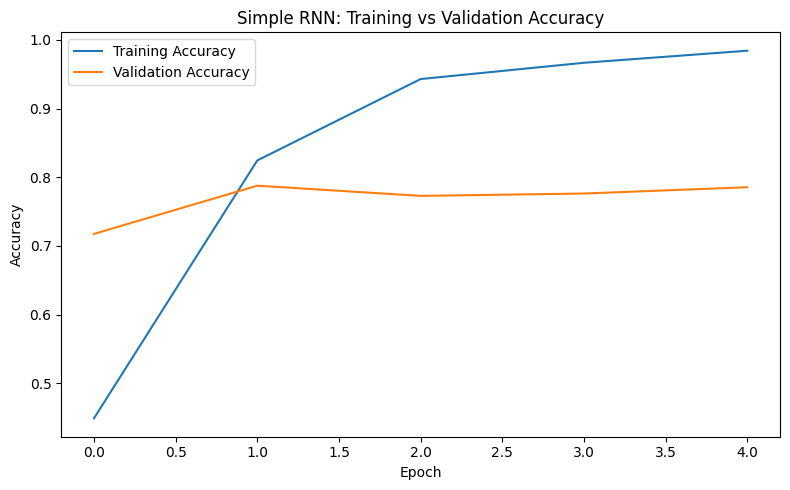

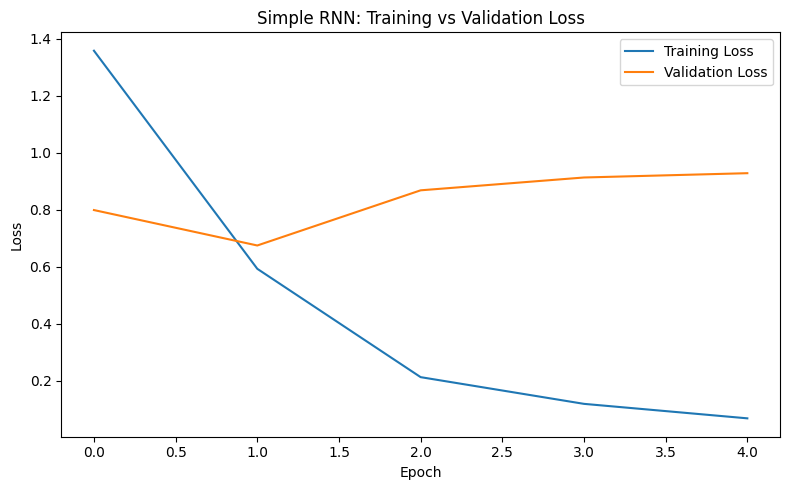


Simple RNN Results
Accuracy : 0.789
Precision: 0.8022
Recall   : 0.789
F1-score : 0.7936

Classification Report:
                 precision    recall  f1-score   support

CULTURE & ARTS       0.64      0.64      0.64       211
     EDUCATION       0.55      0.74      0.63       203
         MONEY       0.73      0.75      0.74       351
        SPORTS       0.93      0.87      0.90      1015
          TECH       0.75      0.73      0.74       410

      accuracy                           0.79      2190
     macro avg       0.72      0.75      0.73      2190
  weighted avg       0.80      0.79      0.79      2190



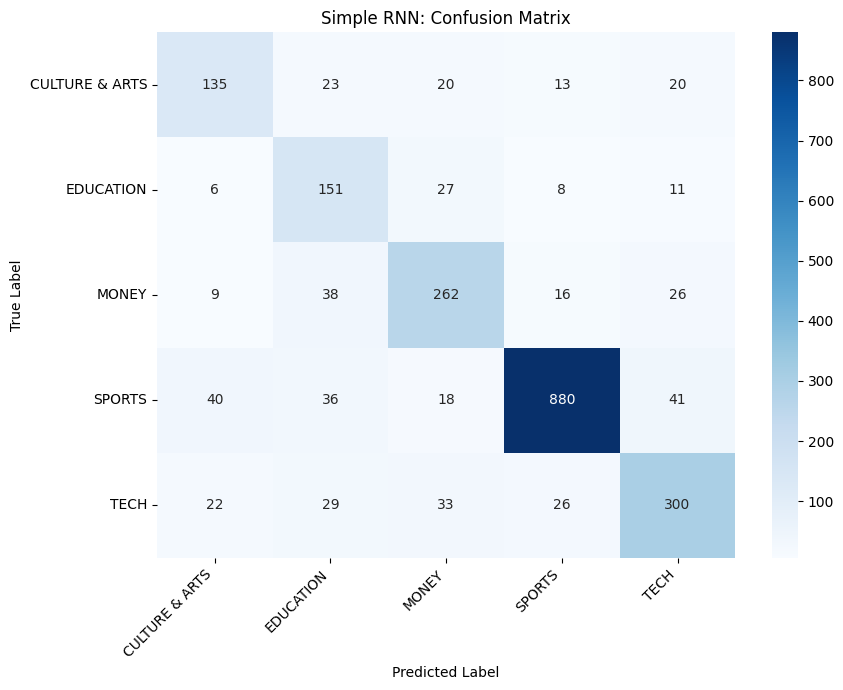

In [16]:
start_time = time.time()

rnn_history = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=RNN_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    class_weight=class_weights,
    verbose=1
)

rnn_time = (time.time() - start_time) / 60
print(f"Simple RNN training time: {rnn_time:.2f} minutes")

plot_history(rnn_history, "Simple RNN")
rnn_results, rnn_pred, rnn_probs = evaluate_model(rnn_model, X_test_pad, y_test, y_test_int, "Simple RNN")
rnn_results["training_time_minutes"] = rnn_time

## 12. Model 2 — LSTM with Trainable Embedding Layer

In [17]:
LSTM_EPOCHS = 8

lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()
save_model_summary(lstm_model, "LSTM")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Model summary saved to: /content/drive/MyDrive/6. News Category Dataset/outputs_nlp/results/lstm_model_summary.txt


Epoch 1/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.4327 - loss: 1.3704 - val_accuracy: 0.7186 - val_loss: 0.7767 - learning_rate: 0.0010
Epoch 2/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7907 - loss: 0.7289 - val_accuracy: 0.7997 - val_loss: 0.6836 - learning_rate: 0.0010
Epoch 3/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9289 - loss: 0.3051 - val_accuracy: 0.8094 - val_loss: 0.6884 - learning_rate: 0.0010
Epoch 4/8
104/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9645 - loss: 0.1632
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9675 - loss: 0.1376 - val_accuracy: 0.8076 - val_loss: 0.8607 - learning_rate: 0.0010
Epoch 5/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9846 - loss: 0.0733 - val_accuracy: 0.8151 - val_loss: 0.8261 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
LSTM 

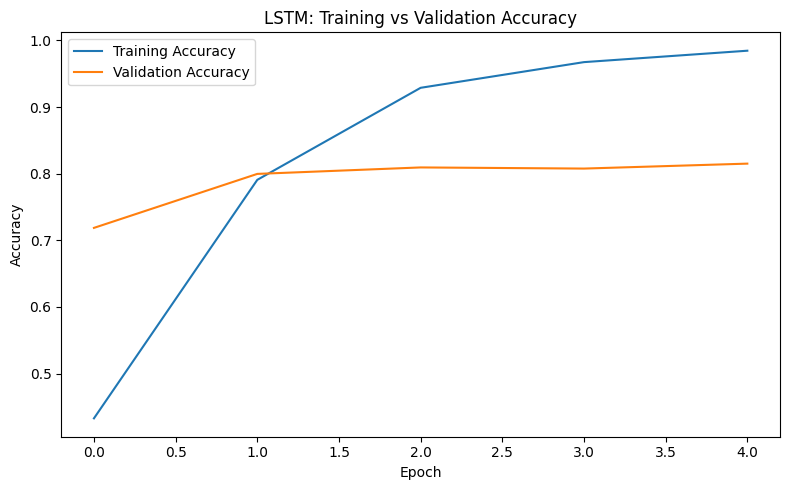

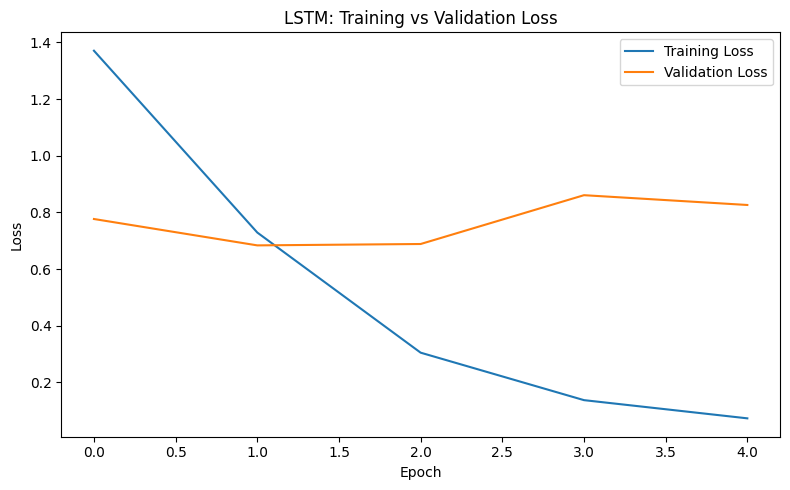


LSTM Results
Accuracy : 0.8132
Precision: 0.8268
Recall   : 0.8132
F1-score : 0.8181

Classification Report:
                 precision    recall  f1-score   support

CULTURE & ARTS       0.51      0.66      0.57       211
     EDUCATION       0.72      0.67      0.70       203
         MONEY       0.74      0.81      0.77       351
        SPORTS       0.95      0.90      0.92      1015
          TECH       0.82      0.76      0.79       410

      accuracy                           0.81      2190
     macro avg       0.75      0.76      0.75      2190
  weighted avg       0.83      0.81      0.82      2190



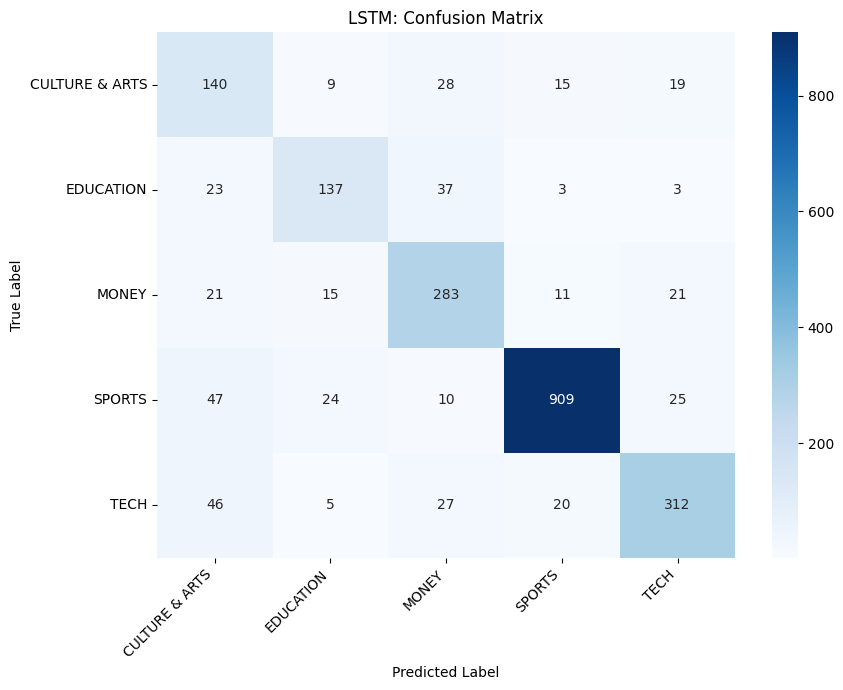

In [18]:
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=LSTM_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    class_weight=class_weights,
    verbose=1
)

lstm_time = (time.time() - start_time) / 60
print(f"LSTM training time: {lstm_time:.2f} minutes")

plot_history(lstm_history, "LSTM")
lstm_results, lstm_pred, lstm_probs = evaluate_model(lstm_model, X_test_pad, y_test, y_test_int, "LSTM")
lstm_results["training_time_minutes"] = lstm_time

## 13. Model 3 — LSTM with Pretrained Word Embeddings

This section uses `gensim.downloader` to load a pretrained GloVe embedding model. The assignment calls this Word2Vec-style pretrained embedding usage. If internet is unavailable, the fallback trains a small Word2Vec model on the training text so the notebook still runs, but for the final assignment use the pretrained GloVe model when possible.

In [20]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.1 MB/s eta 0:00:00


In [21]:
# Load pretrained embedding model using gensim
# GloVe is a pretrained word embedding model and is commonly used similarly to Word2Vec for embedding layers.

EMBEDDING_MODEL_NAME = "glove-wiki-gigaword-50"
PRETRAINED_DIM = 50

try:
    import gensim.downloader as api
    embedding_model = api.load(EMBEDDING_MODEL_NAME)
    pretrained_available = True
    print(f"Loaded pretrained embedding model: {EMBEDDING_MODEL_NAME}")
except Exception as e:
    print("Could not load pretrained embeddings. Error:", e)
    print("Fallback: training Word2Vec on this dataset. For final submission, try to use pretrained embeddings in Colab with internet.")
    from gensim.models import Word2Vec
    tokenized_train_texts = [text.split() for text in X_train]
    w2v_model = Word2Vec(sentences=tokenized_train_texts, vector_size=PRETRAINED_DIM, window=5, min_count=1, workers=4, seed=SEED)
    embedding_model = w2v_model.wv
    pretrained_available = False

# Build embedding matrix
word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, PRETRAINED_DIM))

found_words = 0
for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found_words += 1

print("Embedding matrix shape:", embedding_matrix.shape)
print("Words found in embedding model:", found_words)
print("Coverage percentage:", round(found_words / VOCAB_SIZE * 100, 2), "%")

[==================================================] 100.0% 66.0/66.0MB downloaded
Loaded pretrained embedding model: glove-wiki-gigaword-50
Embedding matrix shape: (11491, 50)
Words found in embedding model: 10830
Coverage percentage: 94.25 %


In [22]:
WORD2VEC_EPOCHS = 8

w2v_lstm_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=PRETRAINED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),
    LSTM(64, return_sequences=False),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

w2v_lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

w2v_lstm_model.summary()
save_model_summary(w2v_lstm_model, "LSTM Word2Vec")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       574,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 574,550 (2.19 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 574,550 (2.19 MB)

Model summary saved to: /content/drive/MyDrive/6. News Category Dataset/outputs_nlp/results/lstm_word2vec_model_summary.txt


Epoch 1/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6207 - loss: 1.1146 - val_accuracy: 0.8031 - val_loss: 0.5947 - learning_rate: 0.0010
Epoch 2/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7904 - loss: 0.6937 - val_accuracy: 0.8293 - val_loss: 0.5092 - learning_rate: 0.0010
Epoch 3/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8097 - loss: 0.6294 - val_accuracy: 0.8293 - val_loss: 0.5128 - learning_rate: 0.0010
Epoch 4/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8223 - loss: 0.5875 - val_accuracy: 0.8350 - val_loss: 0.4854 - learning_rate: 0.0010
Epoch 5/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8264 - loss: 0.5542 - val_accuracy: 0.8430 - val_loss: 0.4664 - learning_rate: 0.0010
Epoch 6/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8408 - loss: 0.5197 - val_accuracy: 0.8408 - val_loss: 0.4602 - learning_rate: 0.0010
Epoch 7/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8527 - loss: 0.4918 - val_

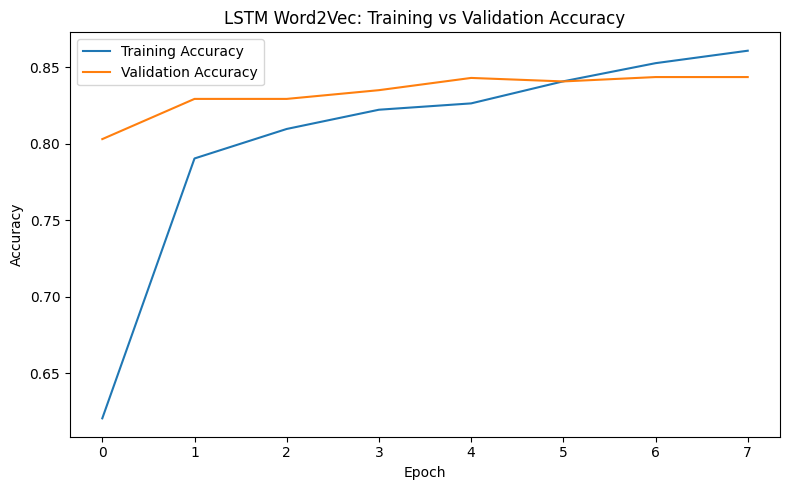

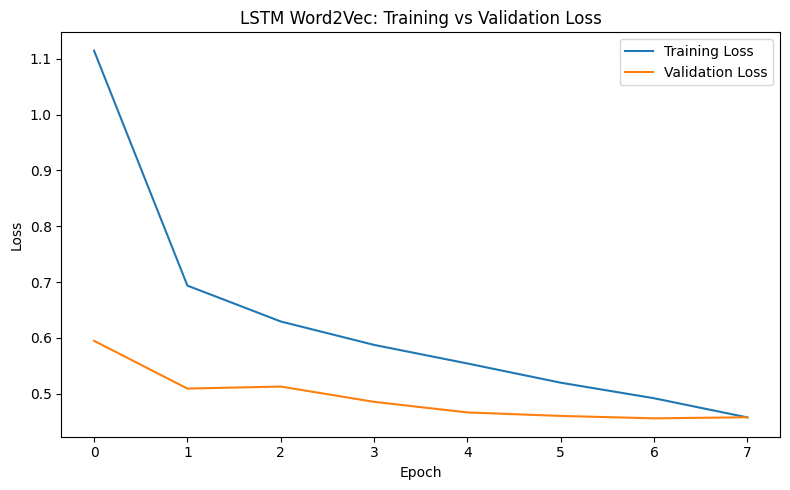


LSTM Word2Vec Results
Accuracy : 0.8452
Precision: 0.8506
Recall   : 0.8452
F1-score : 0.847

Classification Report:
                 precision    recall  f1-score   support

CULTURE & ARTS       0.70      0.81      0.75       211
     EDUCATION       0.76      0.74      0.75       203
         MONEY       0.81      0.82      0.81       351
        SPORTS       0.94      0.89      0.92      1015
          TECH       0.78      0.83      0.80       410

      accuracy                           0.85      2190
     macro avg       0.80      0.82      0.81      2190
  weighted avg       0.85      0.85      0.85      2190



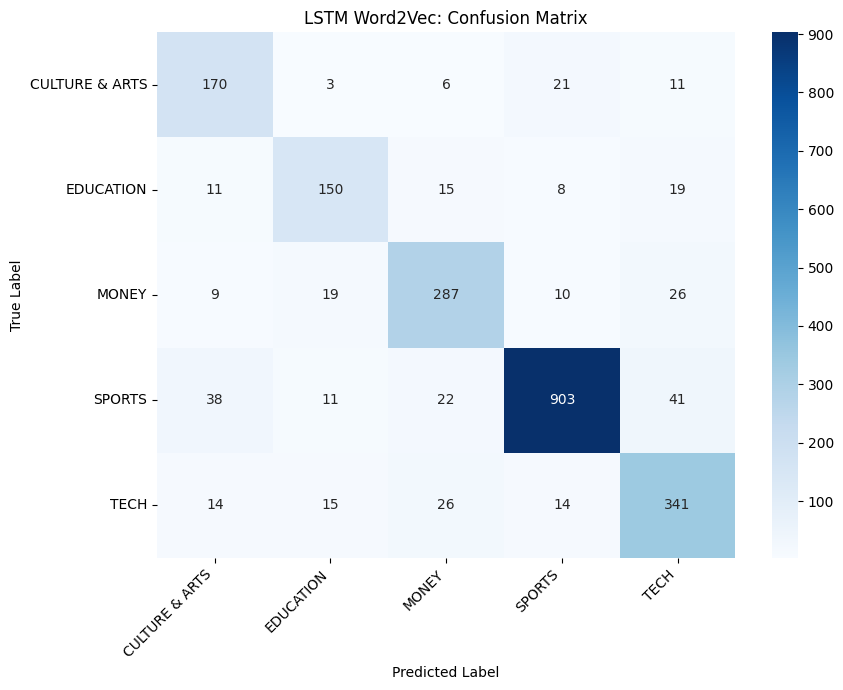

In [23]:
start_time = time.time()

w2v_lstm_history = w2v_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=WORD2VEC_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    class_weight=class_weights,
    verbose=1
)

w2v_lstm_time = (time.time() - start_time) / 60
print(f"LSTM + Word2Vec/GloVe training time: {w2v_lstm_time:.2f} minutes")

plot_history(w2v_lstm_history, "LSTM Word2Vec")
w2v_results, w2v_pred, w2v_probs = evaluate_model(w2v_lstm_model, X_test_pad, y_test, y_test_int, "LSTM Word2Vec")
w2v_results["training_time_minutes"] = w2v_lstm_time
w2v_results["pretrained_embeddings_used"] = pretrained_available

## 14. Final Model Comparison

,model,accuracy,precision,recall,f1_score,training_time_minutes,pretrained_embeddings_used
0,Simple RNN,0.7890,0.8022,0.7890,0.7936,0.2017,NaN
1,LSTM,0.8132,0.8268,0.8132,0.8181,0.2649,NaN
2,LSTM Word2Vec,0.8452,0.8506,0.8452,0.8470,0.1846,True


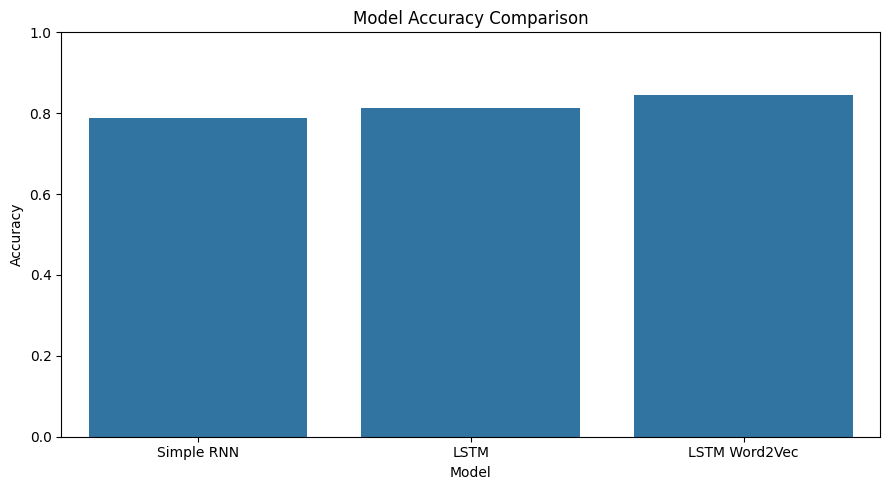

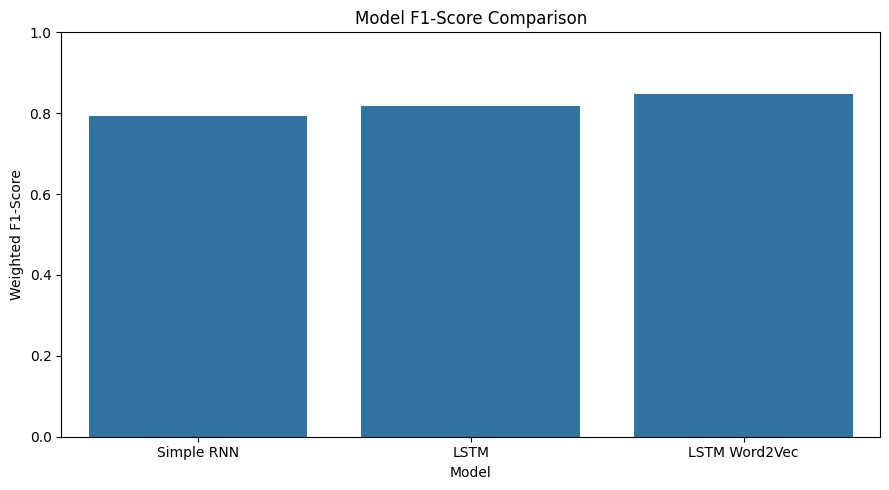

In [24]:
results_df = pd.DataFrame([rnn_results, lstm_results, w2v_results])

# Round for display
results_display = results_df.copy()
for col in ["accuracy", "precision", "recall", "f1_score", "training_time_minutes"]:
    results_display[col] = results_display[col].astype(float).round(4)

display(results_display)
results_df.to_csv(os.path.join(RESULT_DIR, "final_nlp_model_comparison.csv"), index=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="model", y="accuracy")
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "model_accuracy_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="model", y="f1_score")
plt.title("Model F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("Weighted F1-Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "model_f1_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

## 15. Error Analysis

This section shows 2–3 incorrect predictions for the best-performing model.

In [25]:
# Select best model based on F1-score
best_row = results_df.sort_values("f1_score", ascending=False).iloc[0]
best_model_name = best_row["model"]
print("Best model:", best_model_name)

if best_model_name == "Simple RNN":
    best_pred = rnn_pred
    best_probs = rnn_probs
elif best_model_name == "LSTM":
    best_pred = lstm_pred
    best_probs = lstm_probs
else:
    best_pred = w2v_pred
    best_probs = w2v_probs

incorrect_indices = np.where(best_pred != y_test_int)[0]
print("Number of incorrect predictions:", len(incorrect_indices))

error_examples = []
for idx in incorrect_indices[:5]:
    original_text = X_test[idx]
    true_label = class_names[y_test_int[idx]]
    predicted_label = class_names[best_pred[idx]]
    confidence = np.max(best_probs[idx])
    error_examples.append({
        "text": original_text,
        "true_label": true_label,
        "predicted_label": predicted_label,
        "confidence": confidence
    })

error_df = pd.DataFrame(error_examples)
display(error_df)
error_df.to_csv(os.path.join(RESULT_DIR, "misclassified_examples.csv"), index=False)

Best model: LSTM Word2Vec
Number of incorrect predictions: 339


,text,true_label,predicted_label,confidence
0,applying food stamp bachelor degree,MONEY,EDUCATION,0.982921
1,girl stem calling mentor,TECH,EDUCATION,0.692648
2,mini darth vader super bowl ad look like anymore,SPORTS,TECH,0.686715
3,ama rainey black bottom viola davis exciting,CULTURE & ARTS,SPORTS,0.644187
4,refrigerator stay forever dumb,TECH,MONEY,0.378550


## 16. Real-Time Prediction Function

In [26]:
# Choose the best trained model for prediction
if best_model_name == "Simple RNN":
    final_model = rnn_model
elif best_model_name == "LSTM":
    final_model = lstm_model
else:
    final_model = w2v_lstm_model

def predict_category(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    probs = final_model.predict(padded, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_label = class_names[pred_idx]
    confidence = float(np.max(probs))
    return pred_label, confidence

sample_text = "New smartphone update brings AI features and privacy improvements"
pred_label, conf = predict_category(sample_text)
print("Text:", sample_text)
print("Predicted category:", pred_label)
print("Confidence:", round(conf, 4))

Text: New smartphone update brings AI features and privacy improvements
Predicted category: TECH
Confidence: 0.9955


## 17. Optional GUI using Gradio


In [27]:
!pip install -q gradio

import gradio as gr

def gradio_predict(text):
    label, confidence = predict_category(text)
    return {label: confidence}

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(lines=3, placeholder="Enter a news headline here..."),
    outputs=gr.Label(num_top_classes=3),
    title="News Headline Category Classifier",
    description="Predicts the category of a news headline using the best trained RNN/LSTM model."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7d22072024ccf2d409.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 18. Save Trained Models and Outputs

In [28]:
# Save final trained models
rnn_model.save(os.path.join(MODEL_DIR, "simple_rnn_model.keras"))
lstm_model.save(os.path.join(MODEL_DIR, "lstm_model.keras"))
w2v_lstm_model.save(os.path.join(MODEL_DIR, "lstm_word2vec_model.keras"))

# Save tokenizer and label encoder
import pickle
with open(os.path.join(MODEL_DIR, "tokenizer.pkl"), "wb") as f:
    pickle.dump(tokenizer, f)
with open(os.path.join(MODEL_DIR, "label_encoder.pkl"), "wb") as f:
    pickle.dump(label_encoder, f)

print("All outputs saved in:", OUTPUT_DIR)

All outputs saved in: /content/drive/MyDrive/6. News Category Dataset/outputs_nlp
